1. Input Data

In [11]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # cuDNN 确保可复现
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 避免某些算子非确定性
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)


In [12]:
import numpy as np
import torch

# 读入数据（用的是前面保存的“带传感器”的那个文件）
data = np.load("frozen_soil_sensor_dataset_train_80.npz")

all_T        = data["all_T"]         # (n_case, Nt, Nz)   全场温度
all_T_sensor = data["all_T_sensor"]  # (n_case, Nt, n_s)  传感器温度
params_arr   = data["params_arr"]    # (n_case, n_param)  SFCC 参数
curve_ids    = data["curve_ids"]     # (n_case,)
t            = data["t"]             # (Nt,)
z            = data["z"]             # (Nz,)
sensor_z     = data["sensor_z"]      # (n_s,)
sensor_idx   = data["sensor_idx"]    # (n_s,)

print("all_T       :", all_T.shape)
print("all_T_sensor:", all_T_sensor.shape)
print("params_arr  :", params_arr.shape)
print("curve_ids   :", curve_ids.shape)
print("t           :", t.shape)
print("z           :", z.shape)
print("sensor_z    :", sensor_z)
print("sensor_idx  :", sensor_idx)

all_T       : (80, 61, 49)
all_T_sensor: (80, 61, 11)
params_arr  : (80, 6)
curve_ids   : (80,)
t           : (61,)
z           : (49,)
sensor_z    : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
sensor_idx  : [ 4  8 12 16 20 24 28 32 36 40 44]


2. 建立 Inverse DeepONet

2.1 转化数据shape

In [13]:
X_sensor_np = all_T_sensor
X_sensor = torch.from_numpy(X_sensor_np).permute(0, 2, 1).float()

print("X_sensor for CNN:", X_sensor.shape)  # 预期: (120, 6, 61)

X_sensor for CNN: torch.Size([80, 11, 61])


2.2. 网络架构

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    """
    Branch net: 传感器温度时序 -> latent 向量 b(u) ∈ R^p
    输入 X_sensor: (B, n_sensors, Nt)
      B          : batch size
      n_sensors  : 传感器个数 (这里是 6)
      Nt         : 时间步数 (这里是 61)
    输出 b: (B, latent_dim)   <-- 这里的 latent_dim 就是 p
    """
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        # 对时间维做全局平均池化 -> (B, 32)
        self.pool = nn.AdaptiveAvgPool1d(1)  # 捕捉温度平均值
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class InverseTwoParameter(nn.Module):
    """
    Temperature observations -> theta_res and gamma
    -> two-parameter exponential SFCC
    """

    def __init__(
        self,
        n_sensors: int,
        latent_dim: int = 8,
        theta_sat: float = 0.5,
        theta_res_max: float = 0.4,
        gamma_min: float = 0.0,
        gamma_max: float = 10.0,
    ):
        super().__init__()

        self.branch = BranchCNN(n_sensors, latent_dim)

        self.fc_theta_res = nn.Linear(latent_dim, 1)
        self.fc_gamma = nn.Linear(latent_dim, 1)

        self.theta_res_max = theta_res_max

        self.theta_sat = theta_sat
        self.gamma_min = gamma_min
        self.gamma_max = gamma_max

    def predict_parameters(self, X_sensor):
        """
        X_sensor: (B, n_sensors, Nt)

        Returns:
            theta_res: (B, 1)
            gamma:     (B, 1)
        """
        b = self.branch(X_sensor)

        theta_res = self.theta_res_max * torch.sigmoid(self.fc_theta_res(b))

        gamma = self.gamma_min + (
            self.gamma_max - self.gamma_min
        ) * torch.sigmoid(self.fc_gamma(b))

        return theta_res, gamma

    def forward(self, X_sensor, T_query):
        """
        Returns the exponential SFCC evaluated at T_query.

        theta(T) = theta_res
                 + (theta_sat - theta_res)
                 * exp[-(T/gamma)^2]
        """
        device = X_sensor.device
        T_query = T_query.to(device)

        theta_res, gamma = self.predict_parameters(X_sensor)

        # (1, n_T); for T >= 0, x = 0 and theta = theta_sat
        x = torch.clamp(-T_query, min=0.0).view(1, -1)

        theta = theta_res + (
            self.theta_sat - theta_res
        ) * torch.exp(-((x / gamma) ** 2))

        return theta

3. Connect PDE solver

3.1. K and C_eff functions

In [15]:
import torch.nn as nn
import torch.nn.functional as F

# ===== 物性参数（与之前的模拟条件对齐） =====
n_porosity    = 0.5         # 总孔隙度
theta_s_fixed = 1.0 - n_porosity   # 固体体积分数（可以按需要改）

K_s = 8.80*86400       # W/m/K   固体导热率
K_w = 0.56*86400       # W/m/K   水导热率
K_i = 2.26*86400       # W/m/K   冰导热率

C_s = 2.13*1e6         # J/m3/K  固体体积热容
C_w = 4.19e6           # J/m3/K  水体积热容
C_i = 2.13e6           # J/m3/K  冰体积热容

L     = 3.34e5         # J/kg    水的潜热
rho_w = 1000.0         # kg/m3    水的密度


In [16]:
# 工具函数 1：1D 线性插值 θ(T) 或 dθ/dT
def interp_1d(T_nodes: torch.Tensor,
              T_query: torch.Tensor,
              y_query: torch.Tensor) -> torch.Tensor:
    """
    在 T_query 上给出的 y_query(T) 做 1D 线性插值，
    返回 T_nodes 上的 y(T)。

    T_nodes : (...,) 任意形状（温度）
    T_query : (n_T,) 单调升序
    y_query : (n_T,) 对应函数值 y(T_query)

    返回:
      y_nodes: 与 T_nodes 同 shape
    """
    T_min, T_max = T_query[0], T_query[-1]
    T_clamp = torch.clamp(T_nodes, T_min, T_max)

    n_T = T_query.shape[0]
    pos = (T_clamp - T_min) / (T_max - T_min) * (n_T - 1)

    idx0 = torch.floor(pos).long()
    idx1 = torch.clamp(idx0 + 1, max=n_T - 1)
    w    = (pos - idx0.float()).clamp(0.0, 1.0)

    y0 = y_query[idx0]
    y1 = y_query[idx1]
    y  = (1.0 - w) * y0 + w * y1
    return y


# 工具函数 2: 在固定 T_query 上 计算 SFCC 及解析导数 dθ/dT
def sfcc_and_deriv_finite_diff_batch(
    deeponet: nn.Module,
    X_sensor_batch: torch.Tensor,  # (B, n_sensors, Nt)
    T_query: torch.Tensor,         # (n_T,)
    eps_T: float = 0.2,
    dtheta_max: float = 5.0
):
    """
    一次性对一个 batch 计算:
      theta_center: (B, n_T)
      dtheta_query: (B, n_T)
    """
    device = T_query.device
    X_sensor_batch = X_sensor_batch.to(device)
    T_query = T_query.to(device)

    eps = float(eps_T)
    T_min, T_max = T_query[0], T_query[-1]
    T_plus  = torch.clamp(T_query + eps,  T_min, T_max)
    T_minus = torch.clamp(T_query - eps,  T_min, T_max)

    # The two-parameter inverse model supports batch evaluation
    theta_center = deeponet(X_sensor_batch, T_query)   # (B, n_T)
    theta_plus   = deeponet(X_sensor_batch, T_plus)    # (B, n_T)
    theta_minus  = deeponet(X_sensor_batch, T_minus)   # (B, n_T)

    dtheta = (theta_plus - theta_minus) / (2.0 * eps)  # (B, n_T)
    dtheta = torch.clamp(dtheta, 0.0, dtheta_max)

    return theta_center, dtheta



In [17]:
# 由 θ_w 计算 K(T)，由 θ_w & dθ/dT 计算 C_eff(T)
def compute_K_from_theta(theta_w: torch.Tensor) -> torch.Tensor:
    """
    theta_w : (Nz,)
    返回:
      K_T(T) : (Nz,)
    """
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    Ks_part = K_s ** theta_s
    Kw_part = K_w ** theta_w
    Ki_part = K_i ** theta_i

    return Ks_part * Kw_part * Ki_part


def compute_Ceff_from_theta_fdiff(
    theta_w: torch.Tensor,      # (Nz,)
    T_nodes: torch.Tensor,      # (Nz,)
    T_query: torch.Tensor,      # (n_T,)
    dtheta_query: torch.Tensor  # (n_T,)
) -> torch.Tensor:
    """
    C_eff(T) = θ_s C_s + θ_w C_w + θ_i C_i + L ρ_w dθ_w/dT

    输入:
      theta_w     : (Nz,)  当前节点的未冻水体积分数
      T_nodes     : (Nz,)  当前节点温度
      T_query     : (n_T,) DeepONet 的温度网格
      dtheta_query: (n_T,) 在 T_query 上的 dθ/dT
    """
    # 三相体积分数
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    # 显热项
    C_T = theta_s * C_s + theta_w * C_w + theta_i * C_i   # (Nz,)

    # 把 dθ/dT 从 T_query 插值到当前节点温度 T_nodes
    dtheta_nodes = interp_1d(T_nodes, T_query, dtheta_query)  # (Nz,)

    # 加潜热项
    C_eff = C_T + L * rho_w * dtheta_nodes
    return C_eff

3.2 PDE solver

In [18]:
def solve_one_case_with_sfcc_fdiff(
    theta_query: torch.Tensor,   # (n_T,)
    dtheta_query: torch.Tensor,  # (n_T,)
    T_query: torch.Tensor,       # (n_T,)
    z: torch.Tensor,             # (Nz,)
    t: torch.Tensor,             # (Nt,)
    T_initial: float,
    T_top_func
) -> torch.Tensor:
    """
    完全可微的隐式差分 1D 热传导求解器：
    - 不再原地改 T_field 的底层存储
    - 每个时间步生成一个新的 T_next
    - 最后 stack 成 (Nt, Nz)
    """
    device = theta_query.device
    z = z.to(device)
    t = t.to(device)

    dz  = z[1] - z[0]
    dt  = t[1] - t[0]
    Nz  = z.numel()
    Nt  = t.numel()
    dz2 = dz * dz

    # t = 0 时刻的温度向量，作为计算图里的第一个状态
    T0 = torch.full((Nz,), float(T_initial),
                    dtype=torch.float32, device=device)
    T_list = [T0]  # 长度 Nt 的列表，每个元素 (Nz,)

    for n in range(Nt - 1):
        Tn = T_list[-1]   # (Nz,)，注意这里不是 view，而是上一时刻的“新”张量

        # 计算下一时刻的边界温度（与网络无关，用 float 即可）
        time_n1     = float(t[n+1].item())
        T_top_n1    = float(T_top_func(time_n1))

        # === 1) 用 DeepONet 的 θ(T)、dθ/dT 计算物性 ==========
        theta_w = interp_1d(Tn, T_query, theta_query)   # (Nz,)
        K_T     = compute_K_from_theta(theta_w)         # (Nz,)
        C_eff   = compute_Ceff_from_theta_fdiff(
            theta_w, Tn, T_query, dtheta_query
        )                                               # (Nz,)

        # 节点间导热系数
        K_half = 0.5 * (K_T[1:] + K_T[:-1])            # (Nz-1,)

        # === 2) 组装线性方程 A * T_internal = d_vec ==========
        M = Nz - 2  # 内点个数

        a = torch.zeros(M-1, device=device)
        b = torch.zeros(M,   device=device)
        c = torch.zeros(M-1, device=device)
        d_vec = torch.zeros(M, device=device)

        for j in range(1, Nz-1):
            m = j - 1

            # 与 模拟一致：j==1 仍然用 K_half[j-1]
            K_left  = K_half[j-1]     # K_{j-1/2}
            K_right = K_half[j]       # K_{j+1/2}
            Ci      = C_eff[j]

            a_m = -K_left  / dz2
            c_m = -K_right / dz2
            b_m = Ci / dt + (K_left + K_right) / dz2
            d_m = Ci / dt * Tn[j]

            if j == 1:
                b_m = b_m + a_m

            if j == Nz-2:
                d_m -= c_m * T_top_n1

            b[m]     = b_m
            d_vec[m] = d_m
            if m > 0:
                a[m-1] = a_m
            if m < M-1:
                c[m] = c_m


        # === 3) 可微的线性求解器 ============================
        A = torch.diag(b) + torch.diag(a, diagonal=-1) + torch.diag(c, diagonal=1)
        T_internal = torch.linalg.solve(A, d_vec)   # (M,)

        # === 4) 拼出下一时刻的整体温度向量 T_next ==========
        T_next = torch.empty_like(Tn)
        T_next[1:-1] = T_internal
        T_next[0]    = T_next[1]   # zero-flux
        T_next[-1]   = T_top_n1

        # 放进列表，后面时间步会用到
        T_list.append(T_next)

    # 最后 stack 成 (Nt, Nz)
    T_field = torch.stack(T_list, dim=0)   # (Nt, Nz)
    return T_field


3.3 Connect DeepONet and PDE

In [19]:
class FrozenSoilDM(nn.Module):
    """
    DeepONet + PDE solver 的组合算子（batch 版 SFCC）：
    forward:
        输入:
          X_sensor : (B, n_sensors, Nt_obs)
        输出:
          T_all    : (B, Nt, Nz)
          T_sensor : (B, Nt, n_sensors)
    """
    def __init__(self,
                 deeponet: nn.Module,
                 z_grid,
                 t_grid,
                 sensor_idx,
                 T_top_func,
                 T_initial: float,
                 theta_sat: float = 0.5,
                 T_min: float = -15.0,
                 T_max: float = 0.0,
                 n_T_query: int = 100):
        super().__init__()

        self.deeponet       = deeponet
        self.T_initial      = T_initial
        self.T_top_func     = T_top_func
        self.theta_sat      = theta_sat

        # 网格和传感器索引
        z_grid = np.asarray(z_grid, dtype=np.float32)
        t_grid = np.asarray(t_grid, dtype=np.float32)
        self.register_buffer("z", torch.from_numpy(z_grid))
        self.register_buffer("t", torch.from_numpy(t_grid))
        self.register_buffer(
            "sensor_idx",
            torch.as_tensor(sensor_idx, dtype=torch.long)
        )

        # DeepONet 评估 SFCC 的温度网格
        T_query_np = np.linspace(T_min, T_max, n_T_query).astype("float32")
        self.register_buffer("T_query", torch.from_numpy(T_query_np))

    def forward(self, X_sensor: torch.Tensor):
        """
        X_sensor: (B, n_sensors, Nt_obs)

        返回:
          T_all    : (B, Nt, Nz)
          T_sensor : (B, Nt, n_sensors)
        """
        device = X_sensor.device
        B, n_sensors, Nt_obs = X_sensor.shape

        z       = self.z.to(device)
        t       = self.t.to(device)
        T_query = self.T_query.to(device)
        idx_s   = self.sensor_idx.to(device)

        Nz = z.numel()
        Nt = t.numel()
        assert Nt_obs == Nt, "观测时间步数 Nt_obs 必须与 t_grid 的 Nt 一致"

        # ===== 先对整个 batch 一次性计算 SFCC 和导数 =====
        theta_batch, dtheta_batch = sfcc_and_deriv_finite_diff_batch(
            self.deeponet,
            X_sensor,    # (B, n_sensors, Nt)
            T_query,     # (n_T,)
            eps_T=0.2,
            dtheta_max=5.0
        )  # (B, n_T), (B, n_T)

        T_fields = []
        for b in range(B):
            T_field = solve_one_case_with_sfcc_fdiff(
               theta_query=theta_batch[b],
               dtheta_query=dtheta_batch[b],
               T_query=T_query,
               z=z, t=t,
               T_initial=self.T_initial,
               T_top_func=self.T_top_func
            )
            T_fields.append(T_field)

        T_all = torch.stack(T_fields, dim=0)     # (B, Nt, Nz)
        # 提取传感器位置温度
        T_sensor = T_all[:, :, idx_s]   # (B, Nt, n_sensors)

        return T_all, T_sensor


4. Loss function + training

4.1. Loss function

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ===== 4.1 实例化 DeepONet 和 DM 模型 =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_case, n_sensors, Nt = X_sensor.shape
Nz = len(z)

latent_dim = 8       # DeepONet 的 p 维隐空间

# ==== PDE 边界条件 ====
def T_top(time_day: float) -> float:
    if time_day <= 0.5:
        return -5.0
    elif time_day <= 5.0:
        return 0.0

T_initial = -15.0  

# 反演 DeepONet（里面已经包含 BranchCNN + TrunkNet + 单调约束）
parametric_operator = InverseTwoParameter(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=0.5,
    theta_res_max=0.4,
    gamma_min=0.0,
    gamma_max=10.0,
).to(device)

n_trainable = sum(
    p.numel() for p in parametric_operator.parameters()
    if p.requires_grad
)

print("Two-parameter model trainable parameters:", n_trainable)

# PDE + DeepONet 组合算子
dm_model = FrozenSoilDM(
    deeponet=parametric_operator,
    z_grid=z,
    t_grid=t,
    sensor_idx=sensor_idx,
    T_top_func=T_top,
    T_initial=float(T_initial),
    theta_sat=0.5,
    T_min=-15.0,
    T_max=0.0,
    n_T_query=50,   # DeepONet 在 [-15,0] 上的 T 采样点数
).to(device)


# ===== 4.2 构造数据集（只用传感器数据做监督） =====
# 目标：传感器位置的温度时序 (只用它做 loss)
Y_sensor_np = all_T_sensor          # (n_case, Nt, n_sensors)
Y_sensor    = torch.from_numpy(Y_sensor_np).float()  # 同形状

# ----------------------------------------------------------------------------------------------------------
dataset = TensorDataset(X_sensor, Y_sensor)
batch_size = 10                      # 每个 batch 做 10 条 SFCC 的 PDE 反演
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)


# ===== 4.3 定义优化器和损失函数 =====
optimizer = torch.optim.Adam(dm_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()            # 只对传感器温度做 MSE

dt = float(t[1] - t[0])

# 预计算 d2/dz2 的系数（非均匀网格也适用；只在传感器内点 1..n_s-2 上定义
sensor_z_t = torch.from_numpy(sensor_z).float().to(device)  # (n_sensors,)
z_im1 = sensor_z_t[:-2]   # z_{i-1}
z_i   = sensor_z_t[1:-1]  # z_i
z_ip1 = sensor_z_t[2:]    # z_{i+1}
h1 = (z_i - z_im1).view(1, 1, -1)   # (1,1,n_s-2)
h2 = (z_ip1 - z_i).view(1, 1, -1)   # (1,1,n_s-2)
# three-point second derivative coefficients for nonuniform spacing:
# f''(z_i) ≈ 2*( f_{i-1}/(h1*(h1+h2)) - f_i/(h1*h2) + f_{i+1}/(h2*(h1+h2)) )
coef_im1 = 2.0 / (h1 * (h1 + h2))
coef_i   = -2.0 / (h1 * h2)
coef_ip1 = 2.0 / (h2 * (h1 + h2))

lam_t  = 0.5   # dT/dt loss 权重
lam_z2 = 0.1*0.1*0.5*0.5   # d2T/dz2 loss 权重（先小一点）

# ===== 4.4 训练循环 =====
n_epochs = 200
early_stop_T = 0.02  # 早停阈值：epoch_T < 0.02

loss_hist      = []
loss_T_hist    = []
loss_dTdt_hist = []
loss_d2z_hist  = []

import time

if device.type == "cuda":
    torch.cuda.synchronize()

training_start = time.perf_counter()

for epoch in range(1, n_epochs + 1):
    dm_model.train()
    running_loss = 0.0
    running_T    = 0.0
    running_dTdt = 0.0
    running_d2z  = 0.0
    n_seen       = 0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()

        _, T_sensor_pred = dm_model(X_batch)

        # -------- (1) 温度损失 --------
        loss_T = criterion(T_sensor_pred, Y_batch)

        # -------- (2) dT/dt 损失（时间维前向差分）--------
        dTdt_pred = (T_sensor_pred[:, 1:, :] - T_sensor_pred[:, :-1, :]) / dt  # (B, Nt-1, n_s)
        dTdt_obs  = (Y_batch[:, 1:, :]       - Y_batch[:, :-1, :])       / dt
        loss_dTdt = criterion(dTdt_pred, dTdt_obs)

        # -------- (3) d2T/dz2 损失（传感器内点 1..n_s-2；非均匀z三点公式）--------
        # 取相邻三点：[:, :, i-1], [:, :, i], [:, :, i+1]
        Tm1_pred = T_sensor_pred[:, :, :-2]   # (B, Nt, n_s-2)
        Ti_pred  = T_sensor_pred[:, :, 1:-1]  # (B, Nt, n_s-2)
        Tp1_pred = T_sensor_pred[:, :, 2:]    # (B, Nt, n_s-2)
        d2Tdz2_pred = coef_im1 * Tm1_pred + coef_i * Ti_pred + coef_ip1 * Tp1_pred

        Tm1_obs = Y_batch[:, :, :-2]
        Ti_obs  = Y_batch[:, :, 1:-1]
        Tp1_obs = Y_batch[:, :, 2:]
        d2Tdz2_obs = coef_im1 * Tm1_obs + coef_i * Ti_obs + coef_ip1 * Tp1_obs

        loss_d2Tdz2 = criterion(d2Tdz2_pred, d2Tdz2_obs)

        # -------- (4) 总损失 --------
        loss_t  = lam_t  * loss_dTdt
        loss_z2 = lam_z2 * loss_d2Tdz2
        loss = loss_T + loss_t + loss_z2 

        loss.backward()
        torch.nn.utils.clip_grad_norm_(dm_model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = X_batch.size(0)
        n_seen += bs
        running_T    += loss_T.item()        * bs
        running_dTdt += loss_t.item()        * bs  
        running_d2z  += loss_z2.item()       * bs
        running_loss += loss.item()          * bs

    epoch_loss  = running_loss / n_seen
    epoch_T     = running_T    / n_seen
    epoch_dTdt  = running_dTdt / n_seen
    epoch_d2z   = running_d2z  / n_seen

    loss_hist.append(epoch_loss)
    loss_T_hist.append(epoch_T)
    loss_dTdt_hist.append(epoch_dTdt)
    loss_d2z_hist.append(epoch_d2z)

    print(
        f"Epoch {epoch:03d} | "
        f"total={epoch_loss:.3e} | "
        f"T={epoch_T:.3e} | "
        f"lam_t*dTdt={epoch_dTdt:.3e} | "     
        f"lam_z2*d2Tdz2={epoch_d2z:.3e}"   
    )

    # -------- 早停：温度损失小于阈值 --------
    if epoch_T < early_stop_T:
        print(f"Early stop at epoch {epoch:03d} (T loss {epoch_T:.3e} < {early_stop_T})")
        break

if device.type == "cuda":
    torch.cuda.synchronize()

training_time = time.perf_counter() - training_start

print(f"Training time: {training_time:.2f} s")
print(f"Epochs completed: {len(loss_hist)}")
print(f"Trainable parameters: {n_trainable}")

Using device: cuda
Two-parameter model trainable parameters: 3834
Epoch 001 | total=6.299e+00 | T=3.177e+00 | lam_t*dTdt=7.071e-01 | lam_z2*d2Tdz2=2.415e+00
Epoch 002 | total=5.870e+00 | T=3.006e+00 | lam_t*dTdt=6.598e-01 | lam_z2*d2Tdz2=2.203e+00
Epoch 003 | total=5.705e+00 | T=2.903e+00 | lam_t*dTdt=6.922e-01 | lam_z2*d2Tdz2=2.111e+00
Epoch 004 | total=5.552e+00 | T=2.824e+00 | lam_t*dTdt=6.676e-01 | lam_z2*d2Tdz2=2.060e+00
Epoch 005 | total=5.142e+00 | T=2.617e+00 | lam_t*dTdt=5.987e-01 | lam_z2*d2Tdz2=1.927e+00
Epoch 006 | total=4.530e+00 | T=2.249e+00 | lam_t*dTdt=5.087e-01 | lam_z2*d2Tdz2=1.772e+00
Epoch 007 | total=3.164e+00 | T=1.429e+00 | lam_t*dTdt=4.161e-01 | lam_z2*d2Tdz2=1.319e+00
Epoch 008 | total=1.806e+00 | T=6.927e-01 | lam_t*dTdt=3.016e-01 | lam_z2*d2Tdz2=8.118e-01
Epoch 009 | total=1.802e+00 | T=6.751e-01 | lam_t*dTdt=3.111e-01 | lam_z2*d2Tdz2=8.153e-01
Epoch 010 | total=1.236e+00 | T=3.977e-01 | lam_t*dTdt=2.513e-01 | lam_z2*d2Tdz2=5.874e-01
Epoch 011 | total=1.200e

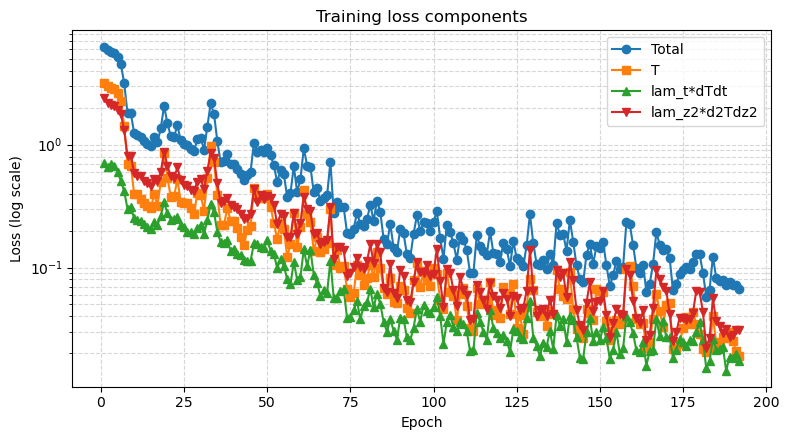

Saved: loss_components.xlsx


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

epochs = np.arange(1, len(loss_hist) + 1)

# ===== 1) 画图（四条曲线） =====
plt.figure(figsize=(8, 4.5))
plt.plot(epochs, loss_hist,      marker="o", label="Total")
plt.plot(epochs, loss_T_hist,    marker="s", label="T")
plt.plot(epochs, loss_dTdt_hist, marker="^", label="lam_t*dTdt")
plt.plot(epochs, loss_d2z_hist,  marker="v", label="lam_z2*d2Tdz2")

plt.yscale("log")  # 强烈建议：量级差很大
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training loss components")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ===== 2) 存为 Excel =====
df = pd.DataFrame({
    "epoch": epochs,
    "loss_total": np.array(loss_hist, dtype=float),
    "loss_T": np.array(loss_T_hist, dtype=float),
    "loss_lam_t_dTdt": np.array(loss_dTdt_hist, dtype=float),
    "loss_lam_z2_d2Tdz2": np.array(loss_d2z_hist, dtype=float),
})

out_xlsx = "loss_components.xlsx"
df.to_excel(out_xlsx, index=False)
print(f"Saved: {out_xlsx}")

4.2. Saving the parameters of DeepONet

In [22]:
# 保存 DeepONet 参数
torch.save(dm_model.deeponet.state_dict(),"two_parameter_operator_train_80.pt")

print("Saved: two_parameter_operator_train_80.pt")

np.savez(
    "two_parameter_training_summary_train80.npz",
    training_time_s=training_time,
    epochs_completed=len(loss_hist),
    trainable_parameters=n_trainable,
)


# 保存得到的高分辨率温度场数据
dm_model.eval()

with torch.no_grad():
    T_all_pred, T_sensor_pred = dm_model(X_sensor.to(device))

# 保存为 numpy，最通用最轻量
np.save("T_all_pred_two_parameter_train_80.npy",T_all_pred.cpu().numpy())
np.save("T_sensor_pred_two_parameter_train_80.npy",T_sensor_pred.cpu().numpy())

print("Saved: T_all_pred_two_parameter_train_80.npy, ""T_sensor_pred_two_parameter_train_80.npy")


Saved: two_parameter_operator_train_80.pt
Saved: T_all_pred_two_parameter_train_80.npy, T_sensor_pred_two_parameter_train_80.npy


In [23]:
T_all_check = np.load("T_all_pred_two_parameter_train_80.npy")
T_sensor_check = np.load("T_sensor_pred_two_parameter_train_80.npy")

print(T_all_check.shape)       # (80, 61, 49)
print(T_sensor_check.shape)    # (80, 61, 11)

(80, 61, 49)
(80, 61, 11)


5. Evaluation

5.1. 加载 DeepONet

In [24]:
import torch
import numpy as np

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

n_case, n_sensors, Nt = X_sensor.shape
latent_dim = 8
theta_sat = 0.5

parametric_operator_eval = InverseTwoParameter(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=theta_sat,
    theta_res_max=0.4,
    gamma_min=0.0,
    gamma_max=10.0,
).to(device)

state_dict = torch.load(
    "two_parameter_operator_train_80.pt",
    map_location=device
)

parametric_operator_eval.load_state_dict(state_dict)
parametric_operator_eval.eval()

print("Loaded two-parameter operator weights.")


Loaded two-parameter operator weights.


5.2. 真实 SFCC

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

theta_sat = 0.5  # 你之前统一的饱和体积含水量

# ===== 1.1 把 params_arr + curve_ids 还原成 DataFrame =====
# 这里假设你当时保存 params_arr 的列顺序是：
# [form_id, theta_res, gamma, a, b, alpha, beta]
# 如果你当时的顺序不同，只要改一下 param_cols 顺序就行
param_cols = ["form_id", "alpha", "beta", "theta_res", "gamma", "n"]
params_df = pd.DataFrame(params_arr, columns=param_cols)
params_df["curve_id"] = curve_ids
print(params_df.head())


   form_id  alpha  beta  theta_res     gamma    n  curve_id
0      2.0    0.0   0.0   0.209365  5.384728  0.0         1
1      2.0    0.0   0.0   0.173501  2.329838  0.0         2
2      2.0    0.0   0.0   0.030974  0.657082  0.0         3
3      2.0    0.0   0.0   0.313877  7.259802  0.0         4
4      2.0    0.0   0.0   0.085769  3.301167  0.0         5


In [26]:
def theta_power_law(T, alpha, beta, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)
    val = alpha * x**beta
    return np.clip(val, 0.0, theta_sat)

# θ = θ_res + (θ_sat - θ_res) * exp(-((T - T0)/γ)^2)
def theta_exponential(T, theta_res, gamma, theta_sat=0.5, T0=0.0):
    T = np.asarray(T, dtype=float)
    val = theta_res + (theta_sat - theta_res) * np.exp(-((T - T0) / gamma)**2)
    return np.clip(val, 0.0, theta_sat)

# VG
def theta_vg(T, theta_res, alpha, n, theta_sat=0.5):
    T = np.asarray(T, dtype=float)
    x = np.maximum(-T, 1e-6)   # 防止 0
    m = 1.0 - 1.0 / n
    val = theta_res + (theta_sat - theta_res) * (1.0 + (alpha * x)**n)**(-m)
    return np.clip(val, 0.0, theta_sat)

# 统一接口：完全按你之前的 theta_w 写法
def theta_w(T, param_row, theta_sat=0.5):
    """
    统一接口：根据 param_row['form_id'] 调用 Form1/2/3.
    param_row: 一行 pandas.Series（params_df.iterrows() 里的 row）
    - form_id = 1: power law      θ = α * (-T)^β
    - form_id = 2: exponential    θ = θ_res + (θ_sat-θ_res)*exp(-((T-T0)/gamma)^2), T0=0
    - form_id = 3: VG simplified  θ = θ_res + (θ_sat-θ_res)*[1+(α*(-T))^n]^(-m), m=1-1/n
    """
    form = int(param_row["form_id"])  # 1, 2, or 3

    if form == 1:
        return theta_power_law(
            T,
            param_row["alpha"],
            param_row["beta"],
            theta_sat=theta_sat,
        )

    elif form == 2:
        return theta_exponential(
            T,
            param_row["theta_res"],
            param_row["gamma"],
            theta_sat=theta_sat,
            T0 = 0.0
        )

    elif form == 3:
        return theta_vg(
            T,
            param_row["theta_res"],
            param_row["alpha"],
            param_row["n"],
            theta_sat=theta_sat
        )
        
    else:
        raise ValueError(f"未知 form_id={form}，期望是 1/2/3")


In [27]:
# 评估用温度网格（和训练范围一致即可）
T_eval_np = np.linspace(-15.0, 0.0, 50).astype("float32")
n_T_eval = T_eval_np.shape[0]
n_case = params_arr.shape[0]

theta_true_np = np.zeros((n_case, n_T_eval), dtype=np.float32)

for i in range(n_case):
    row = params_df.iloc[i]
    theta_true_np[i] = theta_w(T_eval_np, row, theta_sat=theta_sat)

print("theta_true_np shape:", theta_true_np.shape)   # (n_case, 50)


theta_true_np shape: (80, 50)


5.3 DeepONet 反演 SFCC

In [28]:
import torch

T_eval = torch.from_numpy(T_eval_np).to(device)          # (n_T_eval,)
X_eval = X_sensor.to(device)                             # (n_case, n_sensors, Nt)

with torch.no_grad():
    theta_pred = parametric_operator_eval(X_eval, T_eval)

    theta_res_pred, gamma_pred = (
        parametric_operator_eval.predict_parameters(X_eval)
    )

theta_pred_np = theta_pred.cpu().numpy()
theta_res_pred_np = theta_res_pred.squeeze(1).cpu().numpy()
gamma_pred_np = gamma_pred.squeeze(1).cpu().numpy()

theta_res_true_np = params_arr[:, 3]
gamma_true_np = params_arr[:, 4]

print("theta_pred_np shape:", theta_pred_np.shape)


theta_pred_np shape: (80, 50)


In [29]:
# 每个 case 上的 MSE / RMSE
sfcc_mse_case = np.mean((theta_pred_np - theta_true_np)**2, axis=1)  # (n_case,)
sfcc_rmse_case = np.sqrt(sfcc_mse_case)

print("Per-case SFCC RMSE: mean / min / max = "
      f"{sfcc_rmse_case.mean():.4f}, "
      f"{sfcc_rmse_case.min():.4f}, "
      f"{sfcc_rmse_case.max():.4f}")


Per-case SFCC RMSE: mean / min / max = 0.0121, 0.0002, 0.0431


In [30]:
err_global = theta_pred_np - theta_true_np

sfcc_rmse_global = np.sqrt(
    np.mean(err_global ** 2)
)

ss_res_global = np.sum(err_global ** 2)

ss_tot_global = np.sum(
    (theta_true_np - np.mean(theta_true_np)) ** 2
)

sfcc_r2_global = (
    1.0 - ss_res_global / ss_tot_global
)

print("Global SFCC RMSE =", sfcc_rmse_global)
print("Global SFCC R2   =", sfcc_r2_global)

Global SFCC RMSE = 0.01541865
Global SFCC R2   = 0.9874969655647874


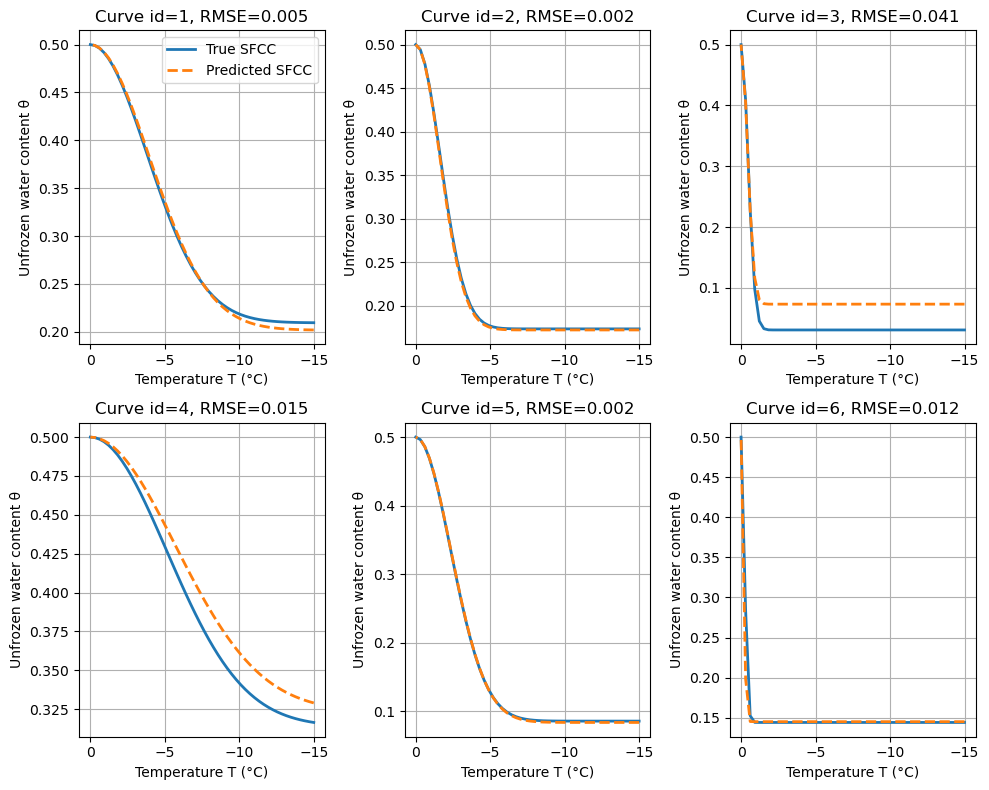

In [31]:
import matplotlib.pyplot as plt

# 按 curve_id 去重，每个 curve_id 选一个代表样本
rep_indices = []
for cid in np.unique(curve_ids):
    idx = np.where(curve_ids == cid)[0][0]
    rep_indices.append(idx)

# 随便挑 6 条代表性的曲线来画（如果不足 6 条就全画）
rep_indices = rep_indices[:6]

plt.figure(figsize=(10, 8))

for k, i in enumerate(rep_indices, 1):
    plt.subplot(2, 3, k)
    plt.plot(T_eval_np, theta_true_np[i], label="True SFCC", linewidth=2)
    plt.plot(T_eval_np, theta_pred_np[i], "--", label="Predicted SFCC", linewidth=2)
    plt.gca().invert_xaxis()  # 让 0 在右，-15 在左，看起来更像冻土习惯
    plt.xlabel("Temperature T (°C)")
    plt.ylabel("Unfrozen water content θ")
    plt.title(f"Curve id={curve_ids[i]}, RMSE={sfcc_rmse_case[i]:.3f}")
    plt.grid(True)
    if k == 1:
        plt.legend()

plt.tight_layout()
plt.show()


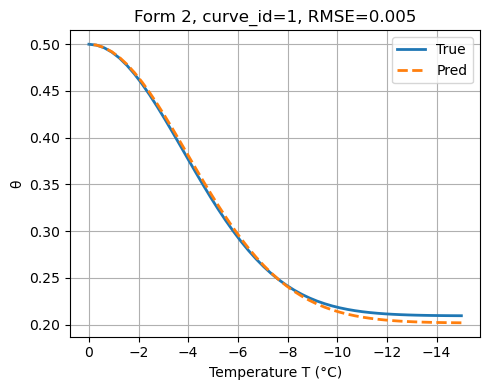

In [32]:
for form in [1, 2, 3]:
    idx_form = np.where(params_df["form_id"].values == form)[0]
    if len(idx_form) == 0:
        continue
    i = idx_form[0]  # 挑这一 form 的第一个 case

    plt.figure(figsize=(5,4))
    plt.plot(T_eval_np, theta_true_np[i], label="True", linewidth=2)
    plt.plot(T_eval_np, theta_pred_np[i], "--", label="Pred", linewidth=2)
    plt.gca().invert_xaxis()
    plt.xlabel("Temperature T (°C)")
    plt.ylabel("θ")
    plt.title(f"Form {form}, curve_id={curve_ids[i]}, RMSE={sfcc_rmse_case[i]:.3f}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
